# 02_EDA - Exploratory Data Analysis

### Obiettivi:
- esplorazione statistica del dataset;
- selezione di un campione stratificato di 10000 utenti;
- definizione delle coorti;
- definizione della finestra temporale;
- analisi preliminare dell'evoluzione della diversità;
- costruzione delle principali visualizzazioni esplorative.

### Setup

#### Import delle librerie

In [44]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

print("Ambiente configurato correttamente")


Ambiente configurato correttamente


#### Definizione dei percorsi

In [45]:
cwd = Path.cwd()

if cwd.name == "notebooks":
    project_root = cwd.parent
else:
    project_root = cwd

data_processed = project_root / "data" / "processed"

print("Project root:", project_root)

Project root: /Users/sofiadimaggio/Desktop/uni/3 anno/Tirocinio_MovieLens


#### Caricamento del dataset e controllo della struttura

In [46]:
df = pd.read_parquet(data_processed / "user_year_genre_longitudinal.parquet")
print(df.shape)
df.info()

(101722, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101722 entries, 0 to 101721
Data columns (total 26 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   userId          101722 non-null  int64  
 1   year            101722 non-null  int32  
 2   Action          101722 non-null  float64
 3   Adventure       101722 non-null  float64
 4   Animation       101722 non-null  float64
 5   Children        101722 non-null  float64
 6   Comedy          101722 non-null  float64
 7   Crime           101722 non-null  float64
 8   Documentary     101722 non-null  float64
 9   Drama           101722 non-null  float64
 10  Fantasy         101722 non-null  float64
 11  Film-Noir       101722 non-null  float64
 12  Horror          101722 non-null  float64
 13  IMAX            101722 non-null  float64
 14  Musical         101722 non-null  float64
 15  Mystery         101722 non-null  float64
 16  Romance         101722 non-null  float64
 1

#### Preparazione delle variabili per le regressioni a effetti fissi

In [47]:
df["log_ratings"] = np.log1p(df["n_ratings_year"])

#### Demeaning per entropia sul campione totale

In [48]:
cols_entropy = ["entropy", "active_year", "log_ratings"]
for col in cols_entropy:
    df[f"{col}_dm"] = df[col] - df.groupby("userId")[col].transform("mean")

#### Demeaning per novelty sul campione totale

In [49]:
sample_novelty = df[df["active_year"] >= 2].copy()

cols_novelty = ["novelty_pct", "active_year", "log_ratings"]
for col in cols_novelty:
    sample_novelty[f"{col}_dm"] = sample_novelty[col] - sample_novelty.groupby("userId")[col].transform("mean")

print(f"Dataset Entropia: {len(df)} osservazioni totali.")
print(f"Dataset Novelty pronto (active_year >= 2): {len(sample_novelty)} osservazioni (escluso il primo anno di utilizzo).")

Dataset Entropia: 101722 osservazioni totali.
Dataset Novelty pronto (active_year >= 2): 72826 osservazioni (escluso il primo anno di utilizzo).


#### Regressione entropia

In [50]:
import statsmodels.formula.api as smf
# regressione per l'Entropia con controlli:
# - effetto fisso utente: gestito via Demeaning (_dm)
# - controllo volume: log_ratings_dm
# - controllo tempo calendario: C(year)

model_entropy = smf.ols(
    "entropy_dm ~ active_year_dm + log_ratings_dm + C(year)", 
    data=df
).fit(cov_type='cluster', cov_kwds={'groups': df['userId']})

print(" REGRESSIONE EFFETTI FISSI: ENTROPIA (H)")
print(model_entropy.summary().tables[1])

 REGRESSIONE EFFETTI FISSI: ENTROPIA (H)
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.3851      0.002   -231.022      0.000      -0.388      -0.382
C(year)[T.1996]     0.4317      0.004     98.176      0.000       0.423       0.440
C(year)[T.1997]     0.3527      0.004     88.723      0.000       0.345       0.361
C(year)[T.1998]     0.3750      0.008     47.689      0.000       0.360       0.390
C(year)[T.1999]     0.3913      0.004     92.103      0.000       0.383       0.400
C(year)[T.2000]     0.3584      0.003    103.830      0.000       0.352       0.365
C(year)[T.2001]     0.3517      0.003    100.985      0.000       0.345       0.358
C(year)[T.2002]     0.3929      0.004    111.103      0.000       0.386       0.400
C(year)[T.2003]     0.3659      0.004    104.013      0.000       0.359       0.373
C(year)[T.2004]     0.3823      0.0

#### Regressione novelty

In [51]:
# regressione per la Novelty sul sottocampione (active_year >= 2)
model_novelty = smf.ols(
    "novelty_pct_dm ~ active_year_dm + log_ratings_dm + C(year)", 
    data=sample_novelty
).fit(cov_type='cluster', cov_kwds={'groups': sample_novelty['userId']})

print("REGRESSIONE EFFETTI FISSI: NOVELTY")
print(model_novelty.summary().tables[1])

REGRESSIONE EFFETTI FISSI: NOVELTY
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        -5.75e-05   2.92e-05     -1.969      0.049      -0.000   -2.52e-07
C(year)[T.1998]     0.0263      0.005      5.657      0.000       0.017       0.035
C(year)[T.1999]     0.0009      0.003      0.340      0.734      -0.004       0.006
C(year)[T.2000]     0.0118      0.001      9.576      0.000       0.009       0.014
C(year)[T.2001]     0.0016      0.001      1.635      0.102      -0.000       0.004
C(year)[T.2002]    -0.0011      0.001     -1.305      0.192      -0.003       0.001
C(year)[T.2003]  6.164e-05      0.001      0.067      0.947      -0.002       0.002
C(year)[T.2004]    -0.0048      0.001     -6.225      0.000      -0.006      -0.003
C(year)[T.2005]    -0.0045      0.001     -6.227      0.000      -0.006      -0.003
C(year)[T.2006]    -0.0036      0.001    

Le stime a effetti fissi (con errore standard clustered per utente e controlli per anno di calendario e log-volume di attività) evidenziano due dinamiche distinte:
1. Dinamica dell'Entropia ($\beta_{active\_year} = 0.0063, p < 0.001$): Controllando per il volume di rating e gli
   effetti temporali comuni alla piattaforma, l'invecchiamento dell'account risulta associato a un aumento dell'entropia. Gli utenti diversificano maggiormente la ripartizione dei loro voti tra i generi nel corso degli anni.

2. Dinamica della Novelty ($\beta_{active\_year} = -0.0022, p < 0.001$): L'anzianità dell'utente sulla piattaforma è associata ad una diminuzione della quota di nuovi generi esplorati annualmente.  
Questo vuol dire che la scoperta di nuovi generi decresce nel
   tempo. Questo calo è guidato sia dal naturale assestamento delle preferenze, sia dal meccanico effetto soffitto dei 19 generi primari, i quali vengono rapidamente esauriti nelle prime fasi della vita dell'utente.

In [52]:
print(df.columns.tolist())

['userId', 'year', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western', 'entropy', 'novelty_pct', 'n_ratings_year', 'total_ratings', 'active_year', 'log_ratings', 'entropy_dm', 'active_year_dm', 'log_ratings_dm']


#### Diagnosi della saturazione dei generi (effetto soffitto)

In [53]:
# definizione della lista dei 19 generi primari
genre_cols = [
    'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 
    'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 
    'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
]

# calcolo dei generi unici attivati nell'anno corrente (dove il valore > 0)
df['genres_seen_this_year'] = (df[genre_cols] > 0).sum(axis=1)

# aggregazione per anno di attività (active_year)
saturation_summary = (
    df.groupby("active_year")
    .agg(
        avg_genres_per_year=("genres_seen_this_year", "mean"),
        avg_entropy=("entropy", "mean"),
        avg_novelty_pct=("novelty_pct", "mean"),
        n_obs=("userId", "count")
    )
    .reset_index()
)

print(" ANALISI DI SATURAZIONE DEI GENERI PER ANNO DI ATTIVITÀ ")
print(saturation_summary.head(10).to_string(index=False))

 ANALISI DI SATURAZIONE DEI GENERI PER ANNO DI ATTIVITÀ 
 active_year  avg_genres_per_year  avg_entropy  avg_novelty_pct  n_obs
           1            16.836794     3.504237         0.999704  28896
           2            13.878115     3.263366         0.056378  28896
           3            13.866045     3.268848         0.016552  12982
           4            13.926299     3.274318         0.009278   8141
           5            14.016738     3.279216         0.005735   5616
           6            14.019091     3.286668         0.003946   3981
           7            13.907155     3.278158         0.002109   3005
           8            13.864048     3.286128         0.001616   2317
           9            13.716410     3.271421         0.001351   1816
          10            13.533101     3.253228         0.000942   1435


Dinamica dei consumi annui:
- la Novelty (avg_novelty_pct) diminuisce rapidamente: crolla dal 99.9% nel primo anno al 5.6% nel secondo e scende allo 0.9% nel quarto anno. 
Questo calo non indica necessariamente una riduzione della curiosità degli utenti, ma è principalmente dovuto all'effetto soffitto dei 19 generi disponibili, che vengono esplorati rapidamente.
- avg_genres_per_year & avg_entropy: ogni anno gli utenti guardano circa 13.8 - 14 generi distinti e l'entropia media rimane stabile attorno a 3.26 - 3.28.
- Dimostrazione: gli utenti non stanno affatto restringendo la loro varietà consumata (l'entropia tiene benissimo e  nel modello FE aumenta pure con $\beta = 0.0063$). Smettono solo di scoprire nuovi generi perché li hanno già "sbloccati" tutti nei primi 24 mesi.

In [54]:
# calcolo cumulativo dei generi sbloccati nel tempo per utente
df_sorted = df.sort_values(['userId', 'active_year'])

# per ogni genere, verifico se è stato mai visto fino a quell'anno
cumulative_genres = (df_sorted.groupby('userId')[genre_cols].cummax() > 0).sum(axis=1)
df_sorted['cumulative_genres_count'] = cumulative_genres

# tabella di saturazione cumulativa
cum_saturation = (
    df_sorted.groupby('active_year')
    .agg(
        avg_cumulative_genres=('cumulative_genres_count', 'mean'),
        pct_users_exhausted_15plus=('cumulative_genres_count', lambda x: (x >= 15).mean() * 100)
    )
    .reset_index()
)

print("\n SATURAZIONE CUMULATIVA DEL CATALOGO (MAX 19 GENERI) ")
print(cum_saturation.head(10).to_string(index=False))


 SATURAZIONE CUMULATIVA DEL CATALOGO (MAX 19 GENERI) 
 active_year  avg_cumulative_genres  pct_users_exhausted_15plus
           1              16.836794                   85.461656
           2              17.699820                   94.864341
           3              18.290325                   98.651980
           4              18.547844                   99.471809
           5              18.688568                   99.786325
           6              18.783220                   99.899523
           7              18.837271                   99.933444
           8              18.870522                  100.000000
           9              18.894824                  100.000000
          10              18.919164                  100.000000


- Già al primo anno di attività, gli utenti hanno esplorato in media 16.84 generi su 19 disponibili, e l'85.5% degli utenti ha già raggiunto almeno 15 generi.
- Entro il terzo anno, si arriva a 18.29 generi con il 98.7% degli utenti in condizioni di quasi saturazione.
- Questi risultati mostrano che l'effetto soffitto non è un'ipotesi, ma una conseguenza strutturale della metrica basata sui 19 macro-generi: gli utenti esauriscono rapidamente lo spazio dei generi disponibili.

Conclusione: il calo della Novelty non riflette necessariamente una perdita di curiosità o un restringimento delle preferenze, ma principalmente il limite della granularità del catalogo. Per catturare una reale esplorazione nel lungo periodo sarà quindi necessario utilizzare metriche più fini, ad esempio basate su sottogeneri, Tag Genome o similarità tra film.


### Statistiche descrittive

#### Dimensioni del dataset

In [55]:
print(f"Numero osservazioni: {len(df)}")
print(f"Numero utenti: {df['userId'].nunique()}")
print(f"Anni osservati: {df['year'].min()} - {df['year'].max()} ({df['year'].nunique()} anni totali)")

Numero osservazioni: 101722
Numero utenti: 28896
Anni osservati: 1995 - 2019 (25 anni totali)


#### Entropy e Novelty

In [56]:
cols_to_describe = ["entropy", "novelty_pct"]
desc_df = df[cols_to_describe].describe().T  # T traspone per avere le metriche sulle colonne

# Aggiungiamo la skewness
desc_df["skewness"] = df[cols_to_describe].skew()

print("Statistiche descrittive comparative tra Entropy e Novelty")
display(desc_df.round(4))

Statistiche descrittive comparative tra Entropy e Novelty


,count,mean,std,min,25%,50%,75%,max,skewness
entropy,101722.0,3.3355,0.4088,-0.0,3.2004,3.4616,3.6098,3.9562,-1.8313
novelty_pct,101722.0,0.3035,0.4436,0.0,0.0000,0.0000,1.0000,1.0000,0.9022


#### Attività degli utenti

In [57]:
#calcolo del numero di anni di attività per utente
user_years = (
    df.groupby("userId")
    .size()
    .rename("n_years")
    .reset_index()
)

print("Anni attivita per utente")
display(user_years.head())

print("Statistiche descrittive sul numero di anni di attività per utente")
display(user_years["n_years"].describe().round(2).to_frame(name="Anni Attivi"))

#distribuzione percentuale degli anni di attività
print("Distribuzione utenti per anni di presenza")
freq_years = user_years["n_years"].value_counts(normalize=True).mul(100).round(2).to_frame(name="% Utenti")
display(freq_years.head(10)) 

Anni attivita per utente


,userId,n_years
0,3,4
1,5,2
2,12,12
3,13,3
4,15,2


Statistiche descrittive sul numero di anni di attività per utente


,Anni Attivi
count,28896.00
mean,3.52
std,2.81
min,2.00
25%,2.00
50%,2.00
75%,4.00
max,23.00


Distribuzione utenti per anni di presenza


,% Utenti
n_years,
2,55.07
3,16.75
4,8.74
5,5.66
6,3.38
7,2.38
8,1.73
9,1.32
10,1.14


### Selezione dei campioni di 10000 utenti

#### Caricamento ratings.csv e selezione degli utenti validi

In [58]:
#carichiamo e filtriamo il dataset dei ratings per gli utenti validi presenti nel nostro dataset (28.896 utenti)
valid_user_id = df["userId"].unique()

raw_ratings = pd.read_csv(project_root / "data" / "raw" / "ml-25m" / "ratings.csv")
ratings = raw_ratings[raw_ratings["userId"].isin(valid_user_id)].copy()

print(f"Rating totali caricati per gli utenti validi: {ratings.shape[0]}")

Rating totali caricati per gli utenti validi: 10976342


#### Calcolo attività degli utenti (come numero totale di valutazioni effettuate)

In [59]:
user_activity = (
    ratings.groupby("userId")
           .size()
           .reset_index(name="n_ratings")
)
user_activity.head()

,userId,n_ratings
0,3,656
1,5,101
2,12,736
3,13,412
4,15,70


#### Statistiche dell'attività

In [60]:
user_activity["n_ratings"].describe()

count    28896.000000
mean       379.856797
std        488.817199
min         20.000000
25%        115.750000
50%        238.000000
75%        472.000000
max      32202.000000
Name: n_ratings, dtype: float64

#### Distribuzione dell'attività

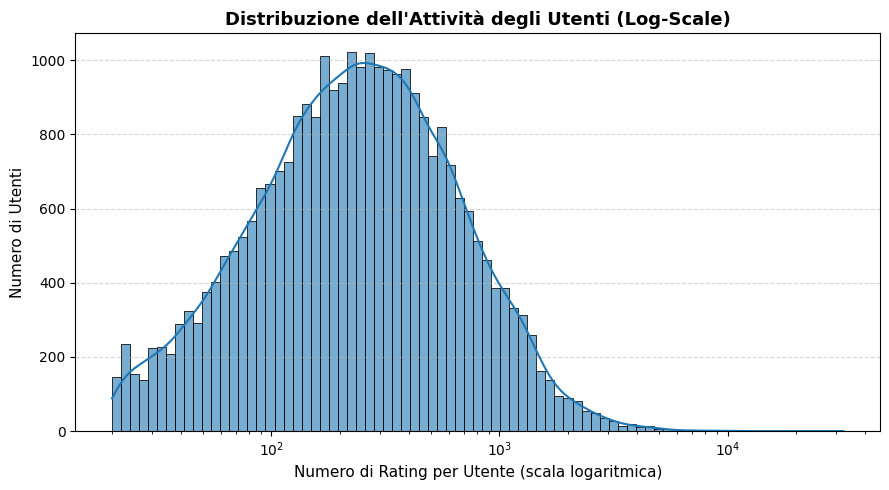

In [61]:
plt.figure(figsize=(9, 5))

# istogramma con scala logaritmica sull'asse X per gestire la forte asimmetria
sns.histplot(user_activity["n_ratings"], log_scale=True, kde=True, color="#1f77b4", edgecolor="black", alpha=0.6)

plt.xlabel("Numero di Rating per Utente (scala logaritmica)", fontsize=11)
plt.ylabel("Numero di Utenti", fontsize=11)
plt.title("Distribuzione dell'Attività degli Utenti (Log-Scale)", fontsize=13, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### Boxplot attività utenti in scala logaritmica

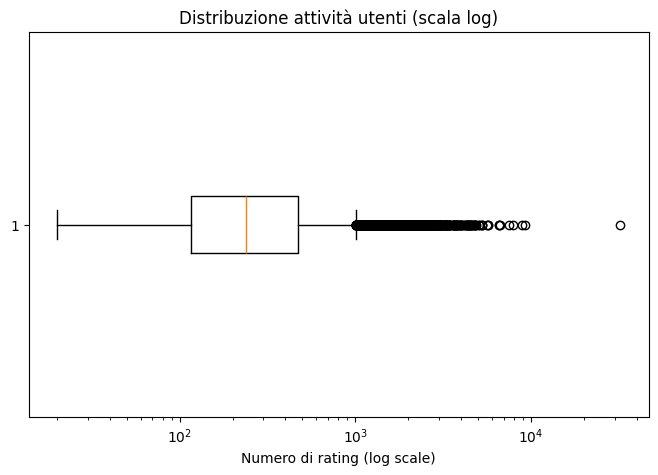

In [62]:
plt.figure(figsize=(8,5))

plt.boxplot(user_activity["n_ratings"], vert=False)

plt.xscale("log")

plt.title("Distribuzione attività utenti (scala log)")
plt.xlabel("Numero di rating (log scale)")

plt.show()

#### Creazione gruppi di attività

In [63]:
user_activity["activity_group"] = pd.qcut(
    user_activity["n_ratings"],
    q=3,
    labels=["Low", "Medium", "High"]
)

print("Distribuzione utenti per gruppo di attività")
user_activity["activity_group"].value_counts().to_frame(name="Conteggio Utenti")

Distribuzione utenti per gruppo di attività


,Conteggio Utenti
activity_group,
Low,9688
High,9610
Medium,9598


#### Estrazione del campione stratificato di 10000 utenti

In [64]:
# campionamento stratificato: 10.000 utenti (3333 Low, 3334 Medium, 3333 High)
samples_per_group = {"Low": 3333, "Medium": 3334, "High": 3333}

sample_users_list = []
for group, n_samples in samples_per_group.items():
    group_df = user_activity[user_activity["activity_group"] == group]
    sampled_group = group_df.sample(n=n_samples, random_state=42)
    sample_users_list.append(sampled_group)

sample_users = pd.concat(sample_users_list).reset_index(drop=True)

print(sample_users.shape)

(10000, 3)


#### Teniamo solo gli ID utenti

In [65]:
sample_user_ids = sample_users["userId"]

df_sample = df[df["userId"].isin(sample_user_ids)].copy()

print(df_sample.shape)

(35624, 31)


#### Integrazione delle informazioni relative al numero totale di rating e al gruppo di apparteneneza nel dataset campionato

In [66]:
df_sample = df_sample.merge(
    user_activity[["userId", "n_ratings", "activity_group"]],
    on="userId",
    how="left"
)
print(df_sample.shape)

(35624, 33)


#### Verifica del dataset finale

In [67]:
print("Numero utenti:", df_sample["userId"].nunique())
print("Numero osservazioni:", len(df_sample))
print("Dimensioni del DataFrame: ", df_sample.shape)

display(df_sample.head())

Numero utenti: 10000
Numero osservazioni: 35624
Dimensioni del DataFrame:  (35624, 33)


,userId,year,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,...,n_ratings_year,total_ratings,active_year,log_ratings,entropy_dm,active_year_dm,log_ratings_dm,genres_seen_this_year,n_ratings,activity_group
0,3,2015,204.0,129.0,29.0,29.0,106.0,67.0,3.0,143.0,...,1239,1239.0,1,7.122867,0.044970,-1.5,1.335940,19,656,High
1,3,2016,15.0,9.0,2.0,2.0,7.0,6.0,0.0,11.0,...,89,89.0,2,4.499810,0.004026,-0.5,-1.287117,15,656,High
2,3,2017,34.0,18.0,6.0,2.0,12.0,14.0,0.0,24.0,...,220,220.0,3,5.398163,-0.065671,0.5,-0.388764,17,656,High
3,3,2019,81.0,42.0,13.0,15.0,51.0,45.0,0.0,54.0,...,457,457.0,4,6.126869,0.016675,1.5,0.339942,18,656,High
4,5,1996,5.0,9.0,3.0,4.0,21.0,8.0,0.0,23.0,...,116,116.0,1,4.762174,0.108746,-0.5,-0.071550,17,101,Low


#### Salvataggio campione

In [68]:
output_path = project_root / "data" / "processed" / "sample_users_10k.parquet"

df_sample.to_parquet(output_path, index=False)

print("Salvato in:", output_path)

Salvato in: /Users/sofiadimaggio/Desktop/uni/3 anno/Tirocinio_MovieLens/data/processed/sample_users_10k.parquet


### Regressione FE sul campione stratificato di 10.000 utenti

In [69]:
import statsmodels.formula.api as smf

# ricalcolo le variabili demeaned all'interno di df_sample
cols_to_dm = ["entropy", "novelty_pct", "active_year", "log_ratings"]

for col in cols_to_dm:
    df_sample[f"{col}_dm"] = df_sample[col] - df_sample.groupby("userId")[col].transform("mean")

# creo il sotto-campione Novelty (active_year >= 2) da df_sample
df_sample_novelty = df_sample[df_sample["active_year"] >= 2].copy()

# ricalcolo il demeaning per la Novelty sul relativo sotto-campione
cols_novelty_dm = ["novelty_pct", "active_year", "log_ratings"]
for col in cols_novelty_dm:
    df_sample_novelty[f"{col}_dm"] = df_sample_novelty[col] - df_sample_novelty.groupby("userId")[col].transform("mean")

# calcolo la regressione FE: Entropia (H) su df_sample
model_entropy_10k = smf.ols(
    "entropy_dm ~ active_year_dm + log_ratings_dm + C(year)", 
    data=df_sample
).fit(cov_type='cluster', cov_kwds={'groups': df_sample['userId']})

# regressione FE: Novelty su df_sample_novelty
model_novelty_10k = smf.ols(
    "novelty_pct_dm ~ active_year_dm + log_ratings_dm + C(year)", 
    data=df_sample_novelty
).fit(cov_type='cluster', cov_kwds={'groups': df_sample_novelty['userId']})


print("REGRESSIONE EFFETTI FISSI (10K SAMPLE): ENTROPIA (H) ")

print(model_entropy_10k.summary().tables[1])

REGRESSIONE EFFETTI FISSI (10K SAMPLE): ENTROPIA (H) 
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0543      0.007      7.785      0.000       0.041       0.068
C(year)[T.1997]    -0.0928      0.013     -7.115      0.000      -0.118      -0.067
C(year)[T.1998]    -0.0772      0.014     -5.664      0.000      -0.104      -0.050
C(year)[T.1999]    -0.0467      0.010     -4.891      0.000      -0.065      -0.028
C(year)[T.2000]    -0.0797      0.009     -9.196      0.000      -0.097      -0.063
C(year)[T.2001]    -0.0842      0.009     -9.534      0.000      -0.102      -0.067
C(year)[T.2002]    -0.0491      0.009     -5.483      0.000      -0.067      -0.032
C(year)[T.2003]    -0.0729      0.009     -8.260      0.000      -0.090      -0.056
C(year)[T.2004]    -0.0603      0.009     -6.985      0.000      -0.077      -0.043
C(year)[T.2005]    -0.

In [70]:

print("REGRESSIONE EFFETTI FISSI (10K SAMPLE): NOVELTY ")
print(model_novelty_10k.summary().tables[1])

REGRESSIONE EFFETTI FISSI (10K SAMPLE): NOVELTY 
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept       -3.645e-05   3.65e-05     -0.999      0.318      -0.000     3.5e-05
C(year)[T.1998]     0.0218      0.005      4.129      0.000       0.011       0.032
C(year)[T.1999]    -0.0008      0.004     -0.186      0.853      -0.009       0.007
C(year)[T.2000]     0.0131      0.002      6.201      0.000       0.009       0.017
C(year)[T.2001]     0.0035      0.002      1.941      0.052   -3.41e-05       0.007
C(year)[T.2002]    -0.0014      0.001     -0.950      0.342      -0.004       0.001
C(year)[T.2003]    -0.0020      0.002     -1.200      0.230      -0.005       0.001
C(year)[T.2004]    -0.0061      0.001     -5.290      0.000      -0.008      -0.004
C(year)[T.2005]    -0.0047      0.001     -4.490      0.000      -0.007      -0.003
C(year)[T.2006]    -0.0024 

### Definizione delle coorti
Per ogni utente vogliamo trovare il primo anno in cui compare nel dataset, questa sarà la sua coorte di appartenenza

#### Creazione coorte

In [71]:
df_sample["cohort_year"] = df_sample.groupby("userId")["year"].transform("min")
df_sample[["userId", "year", "cohort_year"]].head()

,userId,year,cohort_year
0,3,2015,2015
1,3,2016,2015
2,3,2017,2015
3,3,2019,2015
4,5,1996,1996


#### Controllo distribuzione coorti

In [72]:
df_sample["cohort_year"].value_counts().sort_index()

cohort_year
1996    1097
1997     565
1998     434
1999    3813
2000    2957
2001    1672
2002    1421
2003    1589
2004    1673
2005    2314
2006    1600
2007    1740
2008    1929
2009    1464
2010    1441
2011    1168
2012     888
2013     776
2014     789
2015    2387
2016    1740
2017    1433
2018     734
Name: count, dtype: int64

### Definizioni delle finestre temporali
Le analisi longitudinali del progetto possono essere costruite utilizzando differenti definizioni della finestra temporale.

In questo notebook viene adottata la suddivisione per **anno solare**, ottenuta dalla variabile `year` estratta dal timestamp delle valutazioni.

Questa scelta permette di confrontare il comportamento degli utenti tra anni consecutivi ed è coerente con la definizione delle coorti basata sul primo anno di attività.

In [73]:
print("Finestra temporale utilizzata:", "Anno solare")

print(
    "Periodo osservato:",
    df_sample["year"].min(),
    "-",
    df_sample["year"].max()
)

Finestra temporale utilizzata: Anno solare
Periodo osservato: 1996 - 2019


### Preparazione H(t)
Vogliamo analizzare come cambia l'entropia nel tempo per ogni coorte

#### Entropia media per coorte e anno

In [74]:
cohort_entropy = (
    df_sample
    .groupby(["cohort_year", "active_year"])["entropy"]
    .mean()
    .reset_index()
)

cohort_entropy.head()

,cohort_year,active_year,entropy
0,1996,1,3.504750
1,1996,2,3.136583
2,1996,3,2.521641
3,1997,1,3.364303
4,1997,2,3.170790


#### Plot H(t) per coorte

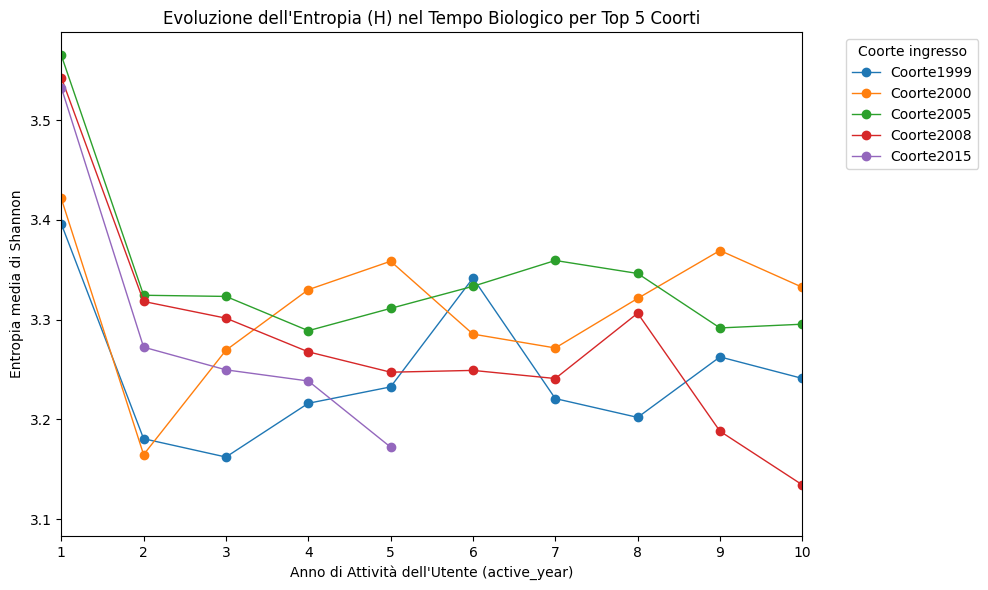

In [75]:
top_cohorts = df_sample["cohort_year"].value_counts().head(5).index
plt.figure(figsize=(10,6))

for cohort in sorted(top_cohorts):
    subset = cohort_entropy[cohort_entropy["cohort_year"] == cohort]
    plt.plot(subset["active_year"], 
             subset["entropy"],
             marker='o',
             linewidth=1,
             label=f"Coorte{cohort}"
    )

plt.title("Evoluzione dell'Entropia (H) nel Tempo Biologico per Top 5 Coorti")
plt.xlabel("Anno di Attività dell'Utente (active_year)")
plt.ylabel("Entropia media di Shannon")
plt.xlim(1, 10) # Primi 10 anni di attività per leggibilità
plt.legend(title="Coorte ingresso", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()

#### Media per coorte

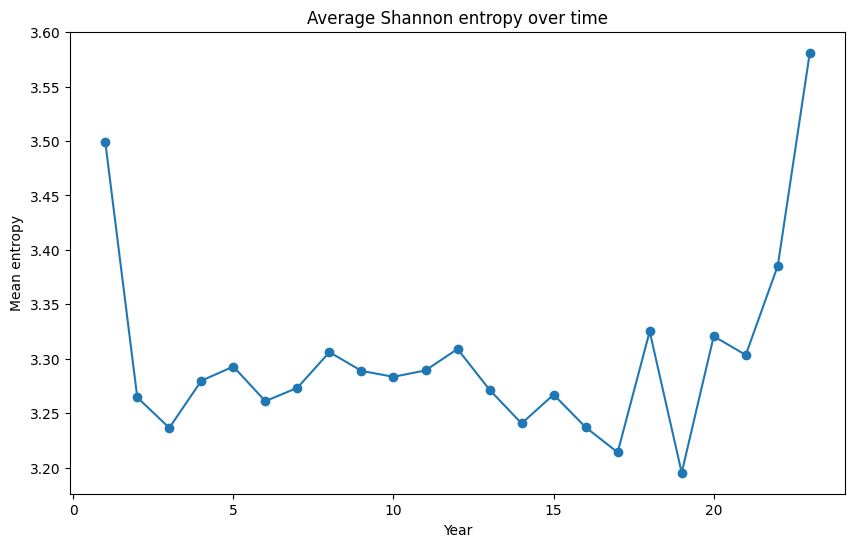

In [76]:
plt.figure(figsize=(10,6))
cohort_mean = (
    cohort_entropy
    .groupby("active_year", as_index=False)["entropy"]
    .mean()
)

plt.plot(
    cohort_mean["active_year"],
    cohort_mean["entropy"],
    marker='o'
)

plt.title("Average Shannon entropy over time")
plt.xlabel("Year")
plt.ylabel("Mean entropy")

plt.show()

### HEATMAP: distribuzione generi per coorte
Per vedere quali generi dominano nelle diverse coorti nel tempo

#### Aggregazione media generi

In [77]:
genre_cols = [
    "Action","Adventure","Animation","Children","Comedy","Crime",
    "Documentary","Drama","Fantasy","Film-Noir","Horror","IMAX",
    "Musical","Mystery","Romance","Sci-Fi","Thriller", "War", "Western"
]

cohort_genres = (
    df_sample
    .groupby(["cohort_year"])[genre_cols]
    .sum()
)

cohort_genres.head()

,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
cohort_year,,,,,,,,,,,,,,,,,,,
1996,20298.0,15269.0,3569.0,7460.0,27823.0,11548.0,432.0,33844.0,6734.0,557.0,3526.0,1081.0,4200.0,4408.0,17089.0,9209.0,21069.0,4049.0,2156.0
1997,12466.0,9224.0,2233.0,3878.0,19321.0,7651.0,615.0,23909.0,4401.0,596.0,3759.0,731.0,2237.0,3904.0,10664.0,6657.0,13348.0,2271.0,1030.0
1998,8447.0,6704.0,1561.0,2858.0,13758.0,5225.0,505.0,17631.0,3152.0,508.0,2491.0,365.0,1697.0,2692.0,7731.0,4946.0,8755.0,2029.0,814.0
1999,71073.0,57425.0,14150.0,23466.0,133241.0,52032.0,6854.0,175092.0,28424.0,5412.0,21915.0,3465.0,16110.0,26614.0,73089.0,40527.0,76927.0,18457.0,7550.0
2000,69320.0,54190.0,13117.0,21988.0,115113.0,44081.0,5142.0,140910.0,26531.0,3735.0,22460.0,3927.0,12429.0,22243.0,58331.0,40557.0,71641.0,14621.0,6301.0


#### Heatmap

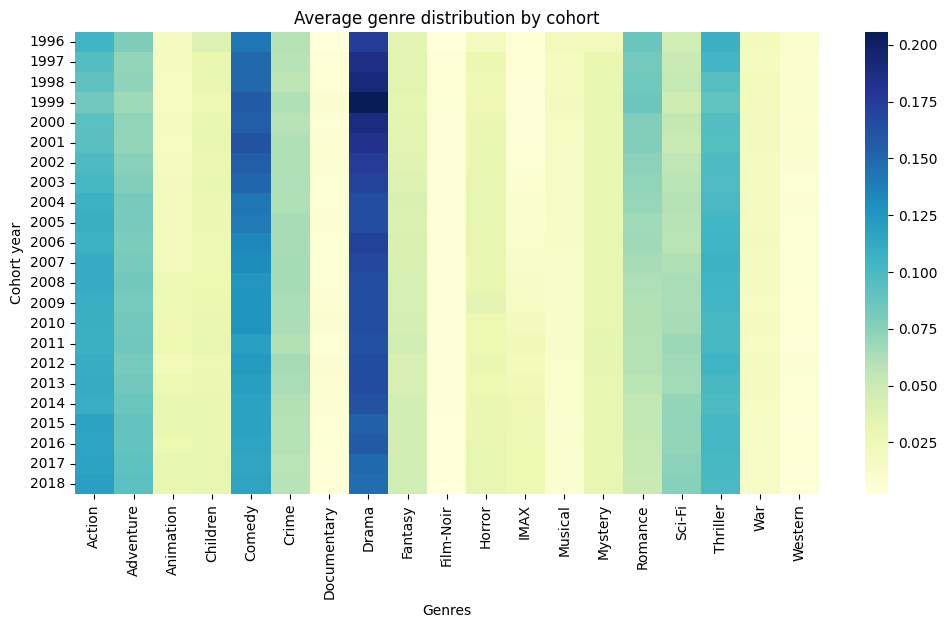

In [78]:
cohort_genres_pct = cohort_genres.div(cohort_genres.sum(axis=1), axis=0)

plt.figure(figsize=(12,6))

sns.heatmap(
    cohort_genres_pct,
    cmap="YlGnBu"
)

plt.title("Average genre distribution by cohort")
plt.xlabel("Genres")
plt.ylabel("Cohort year")

plt.show()

### NOVELTY

#### Distribuzione novelty

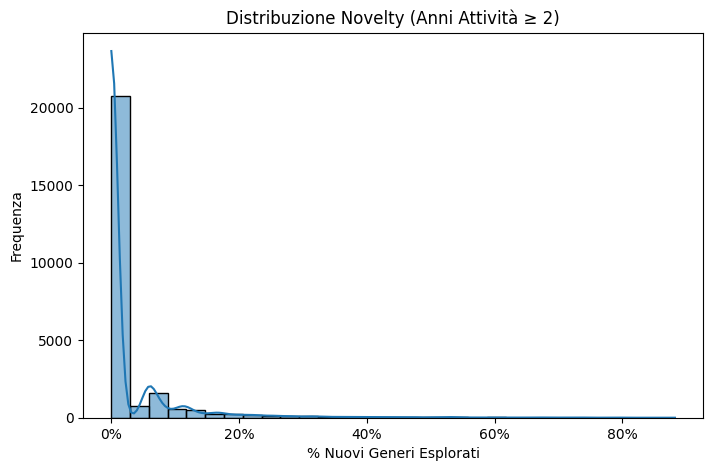

In [79]:
import matplotlib.ticker as mtick
df_sample_novelty = df_sample[df_sample["active_year"] >= 2]

plt.figure(figsize=(8,5))

sns.histplot(
    df_sample_novelty["novelty_pct"],
    bins=30,
    kde=True
)

plt.title("Distribuzione Novelty (Anni Attività ≥ 2)")
plt.xlabel("% Nuovi Generi Esplorati")
plt.ylabel("Frequenza")

plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.show()

#### Novelty nel tempo

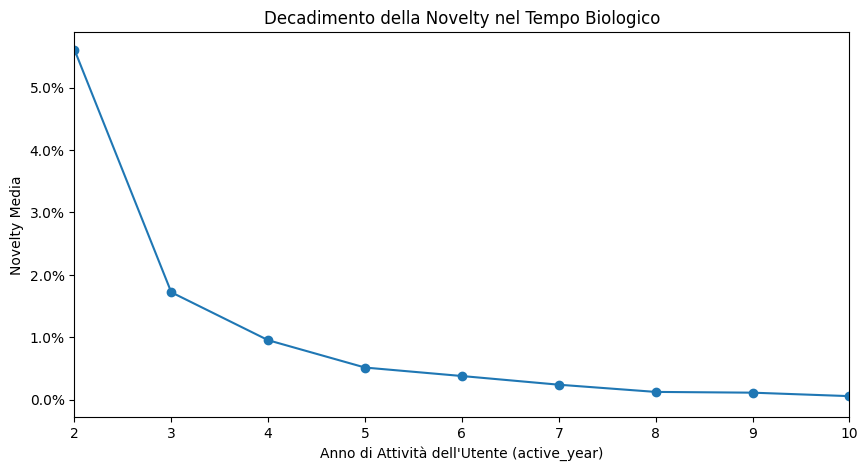

In [80]:
novelty_year = (
    df_sample_novelty
    .groupby("active_year")["novelty_pct"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))

plt.plot(
    novelty_year["active_year"], 
    novelty_year["novelty_pct"], 
    marker="o"
)

plt.title("Decadimento della Novelty nel Tempo Biologico")
plt.xlabel("Anno di Attività dell'Utente (active_year)")
plt.ylabel("Novelty Media")
plt.xlim(2, 10)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.show()

### ENTROPY

#### Distribuzione Entropy

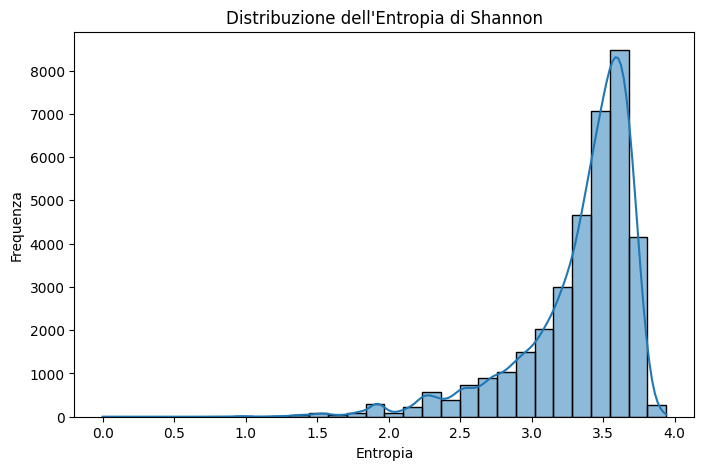

In [81]:
plt.figure(figsize=(8,5))

sns.histplot(
    df_sample["entropy"],
    bins=30,
    kde=True
)

plt.title("Distribuzione dell'Entropia di Shannon")
plt.xlabel("Entropia")
plt.ylabel("Frequenza")

plt.show()

#### Entropy nel tempo

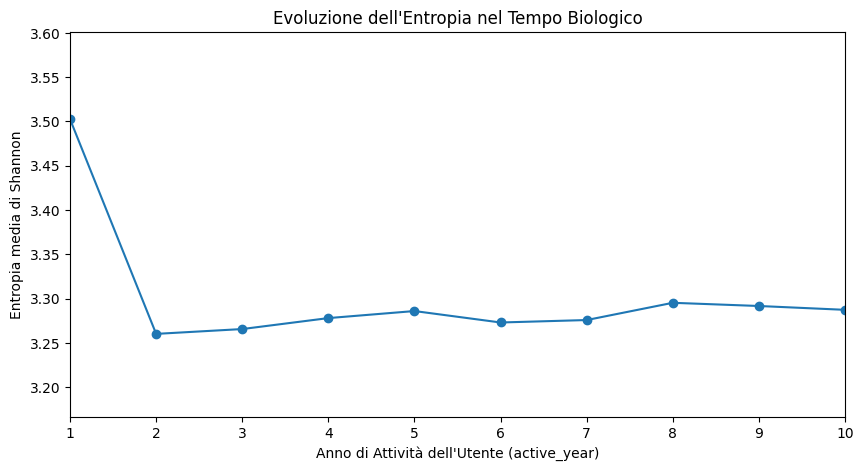

In [82]:
entropy_year = (
    df_sample
    .groupby("active_year")["entropy"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))

plt.plot(
    entropy_year["active_year"],
    entropy_year["entropy"],
    marker="o"
)

plt.title("Evoluzione dell'Entropia nel Tempo Biologico")
plt.xlabel("Anno di Attività dell'Utente (active_year)")
plt.ylabel("Entropia media di Shannon")
plt.xlim(1, 10)

plt.show()

In [83]:
df_sample.columns.tolist()

['userId',
 'year',
 'Action',
 'Adventure',
 'Animation',
 'Children',
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Fantasy',
 'Film-Noir',
 'Horror',
 'IMAX',
 'Musical',
 'Mystery',
 'Romance',
 'Sci-Fi',
 'Thriller',
 'War',
 'Western',
 'entropy',
 'novelty_pct',
 'n_ratings_year',
 'total_ratings',
 'active_year',
 'log_ratings',
 'entropy_dm',
 'active_year_dm',
 'log_ratings_dm',
 'genres_seen_this_year',
 'n_ratings',
 'activity_group',
 'novelty_pct_dm',
 'cohort_year']

In [84]:
import pandas as pd

check = pd.read_parquet("/Users/sofiadimaggio/Desktop/uni/3 anno/Tirocinio_MovieLens/data/processed/sample_users_10k.parquet")

print(check.shape)
print(check.columns.tolist())
print(check[["userId", "year", "active_year"]].head())

(35624, 33)
['userId', 'year', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western', 'entropy', 'novelty_pct', 'n_ratings_year', 'total_ratings', 'active_year', 'log_ratings', 'entropy_dm', 'active_year_dm', 'log_ratings_dm', 'genres_seen_this_year', 'n_ratings', 'activity_group']
   userId  year  active_year
0       3  2015            1
1       3  2016            2
2       3  2017            3
3       3  2019            4
4       5  1996            1
